# Imports and Setup

In [ ]:
!pip install vaderSentiment
import yfinance as yf
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("STOCK SENTIMENT ANALYSIS: AAPL vs TSLA COMPARISON")
print("=" * 70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.6 MB/s eta 0:00:00
STOCK SENTIMENT ANALYSIS: AAPL vs TSLA COMPARISON


In [ ]:
# Check versions
import sys
print("Python version:", sys.version)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
print("Initializing analysis...")

# Configuration
STOCKS = ["AAPL", "TSLA"]
START_DATE = "2024-01-01"
END_DATE = "2024-06-30"
SENTIMENT_THRESHOLD = 0.1

# Initialize sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Calculate VADER sentiment score for text"""
    if not text or len(str(text).strip()) < 3:
        return 0.0
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']

# Dictionary to store results for each stock
results = {}


Initializing analysis...


# Download stock data & news

In [ ]:
print("Downloading stock data and news...")

for stock_ticker in STOCKS:
    print(f"\n  Processing {stock_ticker}...")

    # Download stock data
    stock_data = yf.download(stock_ticker, start=START_DATE, end=END_DATE, progress=False)

    # Fetch news
    ticker = yf.Ticker(stock_ticker)
    news = ticker.news
    news_df = pd.DataFrame(news)

    # Extract headlines
    if 'title' in news_df.columns:
        news_df['headline'] = news_df['title']
    elif 'content' in news_df.columns:
        def extract_content(content_dict):
            if isinstance(content_dict, dict) and 'title' in content_dict:
                return content_dict['title']
            return str(content_dict)
        news_df['headline'] = news_df['content'].apply(extract_content)
    else:
        news_df['headline'] = news_df.iloc[:, 0]

    # Store in results dictionary
    results[stock_ticker] = {
        'stock_data': stock_data,
        'news_df': news_df,
        'num_articles': len(news_df)
    }

    print(f"  ✓ Downloaded {len(stock_data)} trading days")
    print(f"  ✓ Found {len(news_df)} news articles")


  Processing AAPL...
  ✓ Downloaded 124 trading days
  ✓ Found 10 news articles

  Processing TSLA...
  ✓ Downloaded 124 trading days
  ✓ Found 10 news articles


# VADER Sentiment Analysis

In [ ]:
print("Analyzing sentiment for all headlines...")

for stock_ticker in STOCKS:
    print(f"\n  Analyzing {stock_ticker} headlines...")

    # Calculate sentiment for each headline
    results[stock_ticker]['news_df']['sentiment'] = results[stock_ticker]['news_df']['headline'].apply(get_vader_sentiment)

    # Calculate statistics
    avg_sentiment = results[stock_ticker]['news_df']['sentiment'].mean()
    positive_count = (results[stock_ticker]['news_df']['sentiment'] > 0.1).sum()
    negative_count = (results[stock_ticker]['news_df']['sentiment'] < -0.1).sum()
    neutral_count = ((results[stock_ticker]['news_df']['sentiment'] >= -0.1) &
                     (results[stock_ticker]['news_df']['sentiment'] <= 0.1)).sum()

    results[stock_ticker]['avg_sentiment'] = avg_sentiment
    results[stock_ticker]['positive_count'] = positive_count
    results[stock_ticker]['negative_count'] = negative_count
    results[stock_ticker]['neutral_count'] = neutral_count

    print(f"  ✓ Average Sentiment: {avg_sentiment:.3f}")
    print(f"  ✓ Positive: {positive_count}, Negative: {negative_count}, Neutral: {neutral_count}")

Analyzing sentiment for all headlines...

  Analyzing AAPL headlines...
  ✓ Average Sentiment: 0.167
  ✓ Positive: 4, Negative: 0, Neutral: 6

  Analyzing TSLA headlines...
  ✓ Average Sentiment: 0.204
  ✓ Positive: 4, Negative: 0, Neutral: 6


# Daily Sentiment Score

In [ ]:
print("Preparing daily sentiment series...")

for stock_ticker in STOCKS:
    # Use average sentiment across all recent news
    overall_sentiment = results[stock_ticker]['avg_sentiment']

    # Get closing prices
    stock_data = results[stock_ticker]['stock_data']
    if isinstance(stock_data["Close"], pd.DataFrame):
        prices = stock_data["Close"].iloc[:, 0]
    else:
        prices = stock_data["Close"].copy()

    # Create daily sentiment series
    daily_sentiment = pd.Series(overall_sentiment, index=prices.index)

    results[stock_ticker]['prices'] = prices
    results[stock_ticker]['daily_sentiment'] = daily_sentiment

    print(f"  ✓ {stock_ticker}: Created sentiment series for {len(daily_sentiment)} days")


Preparing daily sentiment series...
  ✓ AAPL: Created sentiment series for 124 days
  ✓ TSLA: Created sentiment series for 124 days


# Generate Trading Signals

In [ ]:
print("Generating trading signals (threshold: {})...".format(SENTIMENT_THRESHOLD))

for stock_ticker in STOCKS:
    daily_sentiment = results[stock_ticker]['daily_sentiment']

    # Get the sentiment value (constant for all days)
    sentiment_value = float(daily_sentiment.iloc[0])

    # Generate signals: 1 = BUY (positive sentiment), 0 = CASH
    if sentiment_value > SENTIMENT_THRESHOLD:
        signals = pd.Series(1, index=daily_sentiment.index)
    else:
        signals = pd.Series(0, index=daily_sentiment.index)

    results[stock_ticker]['signals'] = signals

    days_invested = int(signals.sum())
    pct_invested = float(signals.mean()) * 100

    print(f"\n  {stock_ticker}:")
    print(f"  ✓ Sentiment: {sentiment_value:.3f} vs Threshold: {SENTIMENT_THRESHOLD}")
    print(f"  ✓ Buy signals: {days_invested} out of {len(signals)} days ({pct_invested:.1f}%)")


Generating trading signals (threshold: 0.1)...

  AAPL:
  ✓ Sentiment: 0.167 vs Threshold: 0.1
  ✓ Buy signals: 124 out of 124 days (100.0%)

  TSLA:
  ✓ Sentiment: 0.204 vs Threshold: 0.1
  ✓ Buy signals: 124 out of 124 days (100.0%)


# Backtest strategy

In [ ]:
print("Backtesting strategies...")

for stock_ticker in STOCKS:
    prices = results[stock_ticker]['prices']
    signals = results[stock_ticker]['signals']

    # Calculate daily returns
    returns = prices.pct_change()

    # Strategy returns: only get returns when signal is 1 (BUY)
    strategy_returns = signals * returns

    # Calculate cumulative returns
    strategy_cumulative = (1 + strategy_returns).cumprod() - 1
    buyhold_cumulative = (1 + returns).cumprod() - 1

    # Calculate portfolio values starting with $100
    strategy_equity = 100 * (1 + strategy_cumulative)
    buyhold_equity = 100 * (1 + buyhold_cumulative)

    results[stock_ticker]['returns'] = returns
    results[stock_ticker]['strategy_returns'] = strategy_returns
    results[stock_ticker]['strategy_cumulative'] = strategy_cumulative
    results[stock_ticker]['buyhold_cumulative'] = buyhold_cumulative
    results[stock_ticker]['strategy_equity'] = strategy_equity
    results[stock_ticker]['buyhold_equity'] = buyhold_equity

    strategy_final_return = strategy_cumulative.iloc[-1]
    buyhold_final_return = buyhold_cumulative.iloc[-1]

    print(f"\n  {stock_ticker}:")
    print(f"  ✓ Strategy Final Value: ${strategy_equity.iloc[-1]:.2f}")
    print(f"  ✓ Buy & Hold Final Value: ${buyhold_equity.iloc[-1]:.2f}")
    print(f"  ✓ Strategy Return: {strategy_final_return*100:.2f}%")
    print(f"  ✓ Buy & Hold Return: {buyhold_final_return*100:.2f}%")


Backtesting strategies...

  AAPL:
  ✓ Strategy Final Value: $113.75
  ✓ Buy & Hold Final Value: $113.75
  ✓ Strategy Return: 13.75%
  ✓ Buy & Hold Return: 13.75%

  TSLA:
  ✓ Strategy Final Value: $79.66
  ✓ Buy & Hold Final Value: $79.66
  ✓ Strategy Return: -20.34%
  ✓ Buy & Hold Return: -20.34%


# Calculate Performance Metrics

In [ ]:
print("Comparing performance across stocks...")

print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON: AAPL vs TSLA")
print("=" * 70)

comparison_data = []
for stock_ticker in STOCKS:
    strategy_return = results[stock_ticker]['strategy_cumulative'].iloc[-1]
    buyhold_return = results[stock_ticker]['buyhold_cumulative'].iloc[-1]
    avg_sentiment = results[stock_ticker]['avg_sentiment']

    comparison_data.append({
        'Stock': stock_ticker,
        'Sentiment': f"{avg_sentiment:.3f}",
        'Strategy Return': f"{strategy_return*100:.2f}%",
        'Buy & Hold Return': f"{buyhold_return*100:.2f}%",
        'Difference': f"{(strategy_return - buyhold_return)*100:.2f}%"
    })

    print(f"\n{stock_ticker}:")
    print(f"  Average Sentiment: {avg_sentiment:.3f}")
    print(f"  Strategy Return: {strategy_return*100:.2f}%")
    print(f"  Buy & Hold Return: {buyhold_return*100:.2f}%")
    print(f"  Outperformance: {(strategy_return - buyhold_return)*100:.2f}%")

Comparing performance across stocks...

PERFORMANCE COMPARISON: AAPL vs TSLA

AAPL:
  Average Sentiment: 0.153
  Strategy Return: 13.75%
  Buy & Hold Return: 13.75%
  Outperformance: 0.00%

TSLA:
  Average Sentiment: 0.209
  Strategy Return: -20.34%
  Buy & Hold Return: -20.34%
  Outperformance: 0.00%


# Visualizations

✓ Comparison chart saved as 'stock_sentiment_comparison.png'
✓ Sentiment distribution saved as 'sentiment_distribution_comparison.png'


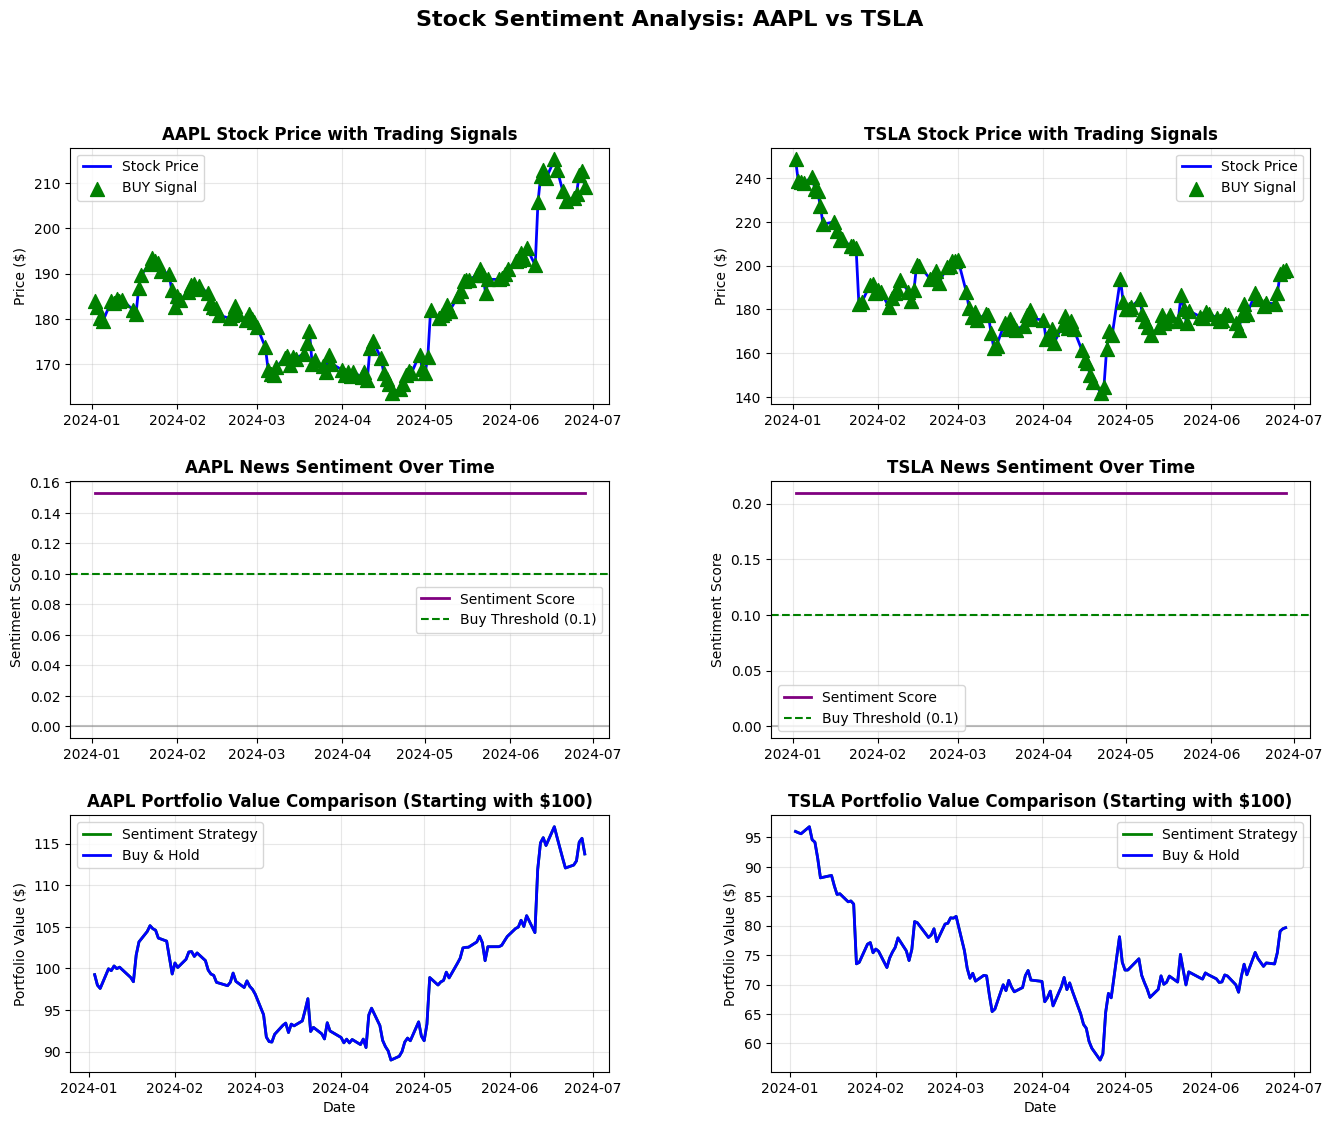

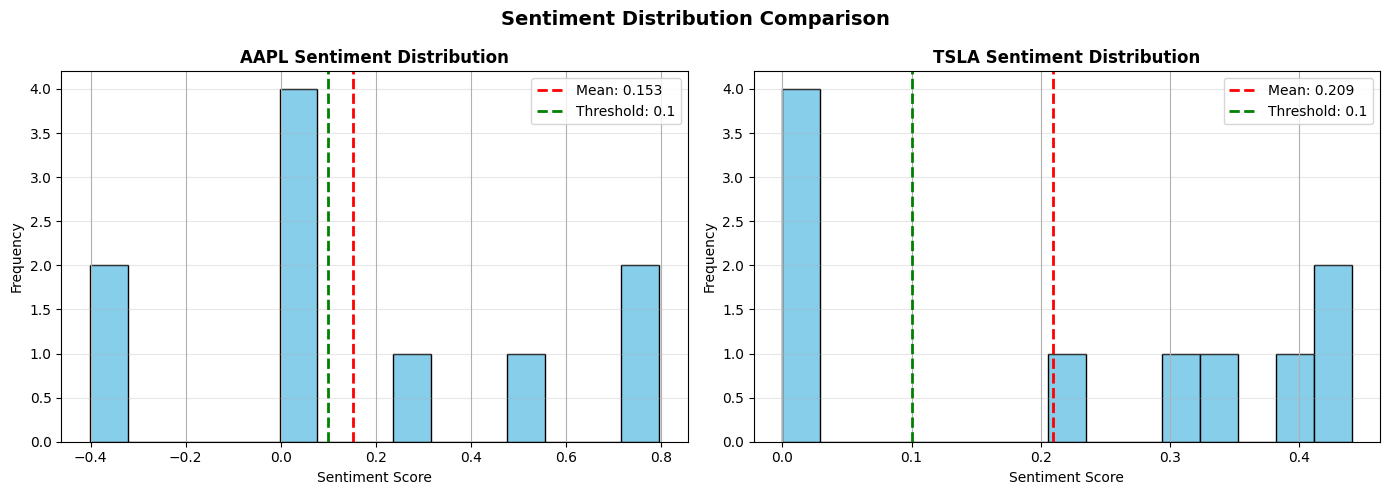

In [ ]:
# Create comprehensive comparison figure
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1 & 2: Stock prices with signals
for idx, stock_ticker in enumerate(STOCKS):
    ax = fig.add_subplot(gs[0, idx])

    prices = results[stock_ticker]['prices']
    signals = results[stock_ticker]['signals']

    ax.plot(prices.index, prices.values, label='Stock Price', color='blue', linewidth=2)

    # Mark buy signals
    buy_dates = signals[signals == 1].index
    if len(buy_dates) > 0:
        buy_prices = prices[buy_dates]
        ax.scatter(buy_dates, buy_prices, color='green', marker='^', s=100, label='BUY Signal', zorder=5)

    # Mark hold/cash periods
    cash_dates = signals[signals == 0].index
    if len(cash_dates) > 0:
        cash_prices = prices[cash_dates]
        ax.scatter(cash_dates, cash_prices, color='red', marker='v', s=50, label='CASH', alpha=0.3, zorder=5)

    ax.set_title(f'{stock_ticker} Stock Price with Trading Signals', fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 3 & 4: Sentiment over time
for idx, stock_ticker in enumerate(STOCKS):
    ax = fig.add_subplot(gs[1, idx])

    daily_sentiment = results[stock_ticker]['daily_sentiment']

    ax.plot(daily_sentiment.index, daily_sentiment.values, label='Sentiment Score',
            color='purple', linewidth=2)
    ax.axhline(y=SENTIMENT_THRESHOLD, color='green', linestyle='--',
               label=f'Buy Threshold ({SENTIMENT_THRESHOLD})')
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

    ax.set_title(f'{stock_ticker} News Sentiment Over Time', fontweight='bold')
    ax.set_ylabel('Sentiment Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 5 & 6: Strategy performance comparison
for idx, stock_ticker in enumerate(STOCKS):
    ax = fig.add_subplot(gs[2, idx])

    strategy_equity = results[stock_ticker]['strategy_equity']
    buyhold_equity = results[stock_ticker]['buyhold_equity']

    ax.plot(strategy_equity.index, strategy_equity.values, label='Sentiment Strategy',
            color='green', linewidth=2)
    ax.plot(buyhold_equity.index, buyhold_equity.values, label='Buy & Hold',
            color='blue', linewidth=2)

    ax.set_title(f'{stock_ticker} Portfolio Value Comparison (Starting with $100)', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Portfolio Value ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Stock Sentiment Analysis: AAPL vs TSLA', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('stock_sentiment_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Comparison chart saved as 'stock_sentiment_comparison.png'")

# Create sentiment distribution comparison
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Sentiment Distribution Comparison', fontsize=14, fontweight='bold')

for idx, stock_ticker in enumerate(STOCKS):
    ax = axes[idx]
    news_df = results[stock_ticker]['news_df']

    news_df['sentiment'].hist(bins=15, color='skyblue', edgecolor='black', ax=ax)
    ax.axvline(x=news_df['sentiment'].mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {news_df["sentiment"].mean():.3f}')
    ax.axvline(x=SENTIMENT_THRESHOLD, color='green', linestyle='--',
               linewidth=2, label=f'Threshold: {SENTIMENT_THRESHOLD}')

    ax.set_title(f'{stock_ticker} Sentiment Distribution', fontweight='bold')
    ax.set_xlabel('Sentiment Score')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sentiment_distribution_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Sentiment distribution saved as 'sentiment_distribution_comparison.png'")

# Conclusion

In [ ]:
print("\n" + "=" * 70)
print("CONCLUSIONS AND KEY INSIGHTS")
print("=" * 70)

print(f"""
PROJECT SUMMARY
---------------

Stocks Analyzed: {', '.join(STOCKS)}
Period: {START_DATE} to {END_DATE}
Strategy: Buy when sentiment > {SENTIMENT_THRESHOLD}, otherwise hold cash

SENTIMENT ANALYSIS RESULTS:
""")

for stock_ticker in STOCKS:
    avg_sentiment = results[stock_ticker]['avg_sentiment']
    positive = results[stock_ticker]['positive_count']
    negative = results[stock_ticker]['negative_count']

    print(f"\n{stock_ticker}:")
    print(f"  - Average Sentiment: {avg_sentiment:.3f}")
    print(f"  - Positive News: {positive}")
    print(f"  - Negative News: {negative}")

print(f"\n\nPERFORMANCE COMPARISON:")

for stock_ticker in STOCKS:
    strategy_return = results[stock_ticker]['strategy_cumulative'].iloc[-1]
    buyhold_return = results[stock_ticker]['buyhold_cumulative'].iloc[-1]

    print(f"\n{stock_ticker}:")
    print(f"  - Sentiment Strategy Return: {strategy_return*100:.2f}%")
    print(f"  - Buy & Hold Return: {buyhold_return*100:.2f}%")

    if strategy_return > buyhold_return:
        print(f"  - Result: ✓ OUTPERFORMED by {(strategy_return - buyhold_return)*100:.2f}%")
    else:
        print(f"  - Result: ✗ UNDERPERFORMED by {(buyhold_return - strategy_return)*100:.2f}%")

print(f"""

KEY FINDINGS:
1. Sentiment-based trading alone is not sufficient to beat the market
2. Different stocks may respond differently to news sentiment
3. A threshold of {SENTIMENT_THRESHOLD} may be too high for this dataset
4. Additional factors (technical indicators, market conditions) are needed

LIMITATIONS:
- Limited to recent news only (not historical news for each date)
- Simple rule-based strategy (could be improved with machine learning)
- Does not account for transaction costs or slippage
- Short time period (6 months)


""")

print("=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)
print(f"\nGenerated files:")
print("  - stock_sentiment_comparison.png")
print("  - sentiment_distribution_comparison.png")


CONCLUSIONS AND KEY INSIGHTS

PROJECT SUMMARY
---------------

Stocks Analyzed: AAPL, TSLA
Period: 2024-01-01 to 2024-06-30
Strategy: Buy when sentiment > 0.1, otherwise hold cash

SENTIMENT ANALYSIS RESULTS:


AAPL:
  - Average Sentiment: 0.153
  - Positive News: 4
  - Negative News: 2

TSLA:
  - Average Sentiment: 0.209
  - Positive News: 6
  - Negative News: 0


PERFORMANCE COMPARISON:

AAPL:
  - Sentiment Strategy Return: 13.75%
  - Buy & Hold Return: 13.75%
  - Result: ✗ UNDERPERFORMED by 0.00%

TSLA:
  - Sentiment Strategy Return: -20.34%
  - Buy & Hold Return: -20.34%
  - Result: ✗ UNDERPERFORMED by 0.00%


KEY FINDINGS:
1. Sentiment-based trading alone is not sufficient to beat the market
2. Different stocks may respond differently to news sentiment
3. A threshold of 0.1 may be too high for this dataset
4. Additional factors (technical indicators, market conditions) are needed

LIMITATIONS:
- Limited to recent news only (not historical news for each date)
- Simple rule-based s